In [1]:
# Load the AzureML Open Datasets Diabetes dataset
from azureml.opendatasets import Diabetes

diabetes = Diabetes.get_tabular_dataset()
diabetes_df = diabetes.to_pandas_dataframe()

print('Shape:', diabetes_df.shape)
print('Columns:', list(diabetes_df.columns))
diabetes_df.head()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
Shape: (442, 11)
Columns: ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [ ]:
# Ordinary Least Squares Linear Regression (scikit-learn)
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Target column in this AzureML version is 'Y'
target_col = 'Y' if 'Y' in diabetes_df.columns else ('target' if 'target' in diabetes_df.columns else None)
if target_col is None:
    raise ValueError(f'Could not find target column. Columns: {list(diabetes_df.columns)}')

X = diabetes_df.drop(columns=[target_col]).astype(float)
y = diabetes_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('Test MSE (LinearRegression):', mse)

Test MSE (LinearRegression): 2900.193628493481


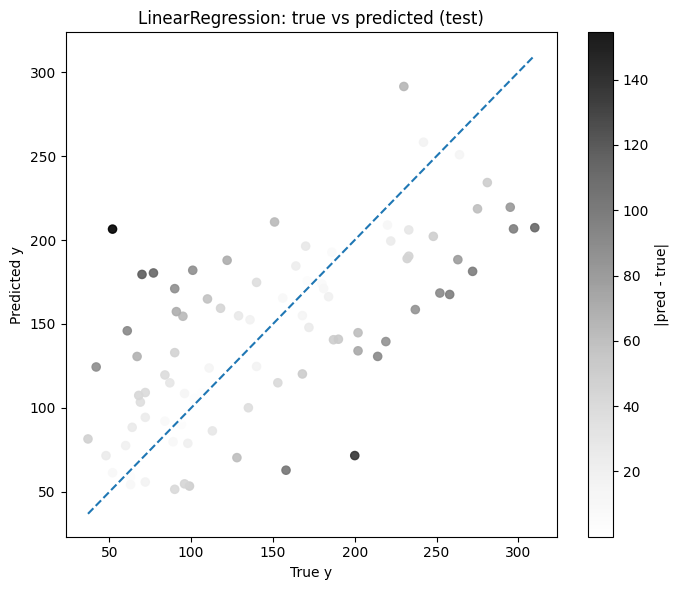

In [5]:
# Simple true-vs-predicted scatter (darker = bigger error). Run after Cell 2
import numpy as np
import matplotlib.pyplot as plt

required = ['y_test', 'y_pred']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing variables {missing}. Run Cell 2 first.')

y_true = np.asarray(y_test, dtype=float)
y_hat = np.asarray(y_pred, dtype=float)
abs_err = np.abs(y_hat - y_true)

vmin = float(min(y_true.min(), y_hat.min()))
vmax = float(max(y_true.max(), y_hat.max()))

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    y_true,
    y_hat,
    c=abs_err,
    cmap='Greys',  # larger error -> darker
    s=35,
    alpha=0.9,
)
plt.plot([vmin, vmax], [vmin, vmax], linestyle='--')
plt.title('LinearRegression: true vs predicted (test)')
plt.xlabel('True y')
plt.ylabel('Predicted y')
cbar = plt.colorbar(sc)
cbar.set_label('|pred - true|')
plt.tight_layout()
plt.show()

In [6]:
#  Kernel Ridge Regression (scikit-learn) with two kernels
import numpy as np
import pandas as pd
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error

required = ['X_train', 'X_test', 'y_train', 'y_test']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing variables {missing}. Run Cell 2 first (it creates the train/test split).')

# Two different kernels: RBF and Polynomial
configs = [
    { 'name': 'rbf', 'model': KernelRidge(alpha=1.0, kernel='rbf', gamma=0.01) },
    { 'name': 'poly', 'model': KernelRidge(alpha=1.0, kernel='polynomial', degree=3, gamma=0.01, coef0=1.0) },
]

results = []
for cfg in configs:
    kr = cfg['model']
    kr.fit(X_train, y_train)
    pred = kr.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results.append({
        'kernel': cfg['name']
        , 'alpha': getattr(kr, 'alpha', None)
        , 'gamma': getattr(kr, 'gamma', None)
        , 'degree': getattr(kr, 'degree', None)
        , 'coef0': getattr(kr, 'coef0', None)
        , 'test_mse': mse
    })

results_df = pd.DataFrame(results).sort_values('test_mse').reset_index(drop=True)
print('Kernels used:', [c['name'] for c in configs])
results_df

Kernels used: ['rbf', 'poly']


,kernel,alpha,gamma,degree,coef0,test_mse
0,poly,1.0,0.01,3,1.0,4029.281661
1,rbf,1.0,0.01,3,1.0,21190.991092


In [ ]:
# Fit the two kernel models on the training data (run after Cell 2)
from sklearn.kernel_ridge import KernelRidge

required = ['X_train', 'y_train', 'X_test']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing variables {missing}. Run Cell 2 first.')

kr_rbf = KernelRidge(alpha=1.0, kernel='rbf', gamma=0.01)
kr_poly = KernelRidge(alpha=1.0, kernel='polynomial', degree=3, gamma=0.01, coef0=1.0)

kr_rbf.fit(X_train, y_train)
kr_poly.fit(X_train, y_train)

# : predictions on the test set (arrays)
y_pred_rbf = kr_rbf.predict(X_test)
y_pred_poly = kr_poly.predict(X_test)

print('Fitted kernels:', ['rbf', 'polynomial'])
print('y_pred_rbf shape:', y_pred_rbf.shape)
print('y_pred_poly shape:', y_pred_poly.shape)

Fitted kernels: ['rbf', 'polynomial']
y_pred_rbf shape: (89,)
y_pred_poly shape: (89,)


Test MSE (RBF kernel): 21190.9911
Test MSE (Polynomial kernel): 4029.2817


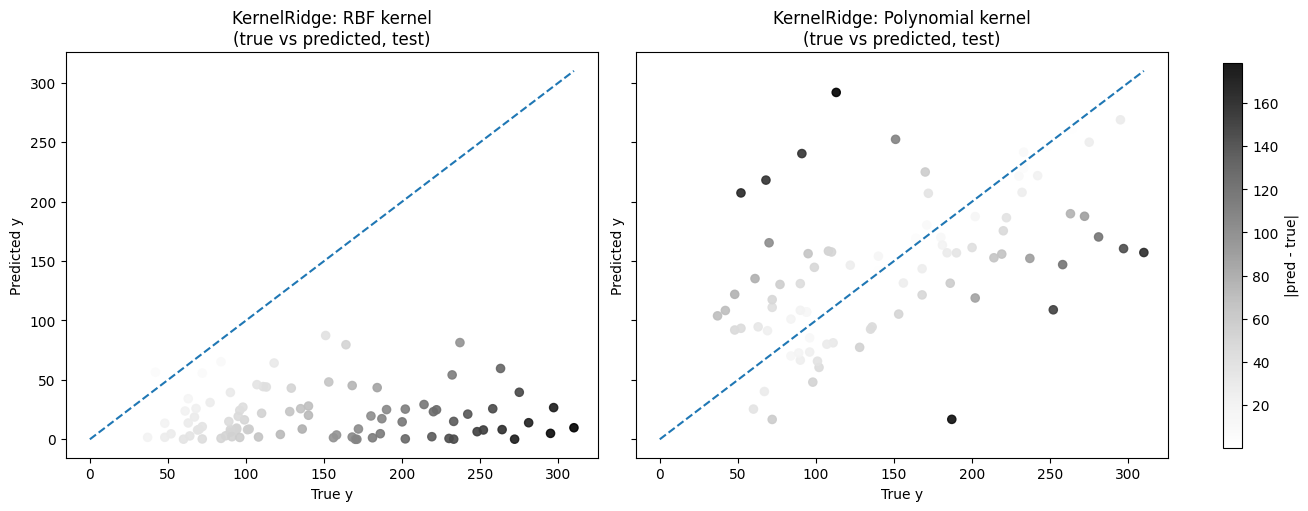

In [10]:
# Test the fitted KernelRidge models on the test set + graph (darker = bigger error)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

required = ['y_test', 'y_pred_rbf', 'y_pred_poly']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables {missing}. Run Cell 2, then Cell 5 (kernel fit) first."
    )

y_true = np.asarray(y_test, dtype=float)
preds = {
    'RBF kernel': np.asarray(y_pred_rbf, dtype=float),
    'Polynomial kernel': np.asarray(y_pred_poly, dtype=float),
}

# Report test MSE for each kernel
for name, y_hat in preds.items():
    mse = mean_squared_error(y_true, y_hat)
    print(f"Test MSE ({name}): {mse:.4f}")

# Shared axis range + style
vmin = float(min([y_true.min()] + [p.min() for p in preds.values()]))
vmax = float(max([y_true.max()] + [p.max() for p in preds.values()]))

# Use constrained_layout to avoid tight_layout+colorbar warnings
fig, axes = plt.subplots(
    1, 2, figsize=(13, 5), sharex=True, sharey=True, constrained_layout=True
 )
for ax, (name, y_hat) in zip(axes, preds.items()):
    abs_err = np.abs(y_hat - y_true)
    sc = ax.scatter(
        y_true,
        y_hat,
        c=abs_err,
        cmap='Greys',  # larger error -> darker
        s=35,
        alpha=0.9,
    )
    ax.plot([vmin, vmax], [vmin, vmax], linestyle='--')
    ax.set_title(f"KernelRidge: {name}\n(true vs predicted, test)")
    ax.set_xlabel('True y')
    ax.set_ylabel('Predicted y')

# One shared colorbar (absolute error)
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.95)
cbar.set_label('|pred - true|')
plt.show()